# Trabajo final IDS - Parte II
## El impacto de la adopción de IA frente a la experiencia tradicional en los salarios de Data Science.
**Integrantes:** Henry Maquera e Ignacio Rojas.

**Fuente del dataset:** https://www.kaggle.com/datasets/uditjain13/ai-and-data-science-job-salaries-2026

**Descripción:** El dataset cuenta con 27 columnas. Cada columna representa la situación laboral de un profesional del área tecnológica. Incluye variables como: el salario, los bonus, la industria donde se trabaja, el tamaño de la compañía, el uso diario de IA, el nivel de experiencia y más.

**Pregunta inicial a explorar:**
La pregunta que queremos explorar es: ¿Hasta qué punto la adopción intensiva de IA compensa la falta o menor experiencia  tradicional en los salarios de data science? Nuestra hipótesis es que los profesionales con alta integración de IA logran salarios superiores a aquellos que cuentan con más años de experiencia pero que no explotan estas herramientas nuevas. 

In [1]:
# Carga de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de datos
df = pd.read_csv("ai_ds_job_salaries_2026.csv")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 5000 filas x 27 columnas


,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,...,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
0,Data Analyst,Lead,Part-time,S,IN,AU,Finance,0,14.4,Bachelors,...,12.5,INR,23844,0.505,11.6,5.5,8,True,2.2,7.4
1,Research Scientist,Senior,Full-time,L,US,US,Retail,50,7.6,Masters,...,2.1,USD,170132,0.054,2.9,7.0,3,False,8.2,5.3
2,Machine Learning Engineer,Entry,Full-time,M,US,US,Government,0,0.0,Bootcamp,...,5.1,USD,83059,0.191,7.5,5.9,1,False,2.8,6.8
3,Data Engineer,Senior,Full-time,M,BR,IN,Government,100,9.7,Masters,...,2.0,BRL,29531,0.102,9.3,5.6,5,False,7.8,5.0
4,Data Engineer,Mid,Full-time,M,US,US,Education,0,3.2,Bachelors,...,4.0,USD,70105,0.064,10.6,4.6,4,False,9.1,5.1


REMOTE RADIO NO PAREE SER CON MUCHOS NUMEROS, YEARS EXPERIENCE TAMPOCO, AI TOOLS HOURS PER WEEK TAMPOCO, SALARY USD SI MASOMENOS PERO MAXIJMO 500000,  EQUITY OFFERED IGUAL MAXIMO 1 PERO DECIMALES HARTO, BONUS PCT FLOU PERO TAMPOCO TANTO, JOBSATISFACTION SCORE TAMPCOO TANTO Y FLOUT, INTERVIEWS TO OFFER POCO NUMERO, SWICH JOBS BINARIO, UPSKILLING HOUR PER MONTH FLOUT POCO, FEAR AI AUTOMATION SCORE FLOUT POCO, COMPANY SIZE S L M COMO CAMBIARLO A STANDAR SCALE, EMPLOYMENT TYPE IGUAL, EXPERIENCE IGUAL

### Inspección general de datos

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_title                   5000 non-null   str    
 1   experience_level            5000 non-null   str    
 2   employment_type             5000 non-null   str    
 3   company_size                5000 non-null   str    
 4   company_location            5000 non-null   str    
 5   employee_residence          5000 non-null   str    
 6   industry                    5000 non-null   str    
 7   remote_ratio                5000 non-null   int64  
 8   years_experience            5000 non-null   float64
 9   education_level             5000 non-null   str    
 10  primary_language            5000 non-null   str    
 11  has_ml_in_title             5000 non-null   bool   
 12  manages_people              5000 non-null   bool   
 13  team_size                   5000 non-null   

In [3]:
print("Valores nulos por columna:")
print(df.isna().sum())
print(f"Filas duplicadas: {df.duplicated().sum()}")


Valores nulos por columna:
job_title                     0
experience_level              0
employment_type               0
company_size                  0
company_location              0
employee_residence            0
industry                      0
remote_ratio                  0
years_experience              0
education_level               0
primary_language              0
has_ml_in_title               0
manages_people                0
team_size                     0
certifications_count          0
weekly_hours                  0
uses_ai_tools_daily           0
ai_tools_hours_per_week       0
salary_currency               0
salary_usd                    0
equity_offered_pct            0
bonus_pct                     0
job_satisfaction_score        0
interviews_to_offer           0
switched_jobs_last_year       0
upskilling_hours_per_month    0
fears_ai_automation_score     0
dtype: int64
Filas duplicadas: 0


### Revisión por columna
Variables categóricas y booleanas.

In [4]:
cat_col = df.select_dtypes(include=["object"]).columns.tolist()
bool_col = df.select_dtypes(include=["bool"]).columns.tolist()

for c in cat_col:
    print(f"{c} ({df[c].nunique()} categorías)")
    print(df[c].value_counts())
    print()


job_title (12 categorías)
job_title
Data Scientist                   709
Data Engineer                    682
Data Analyst                     627
Machine Learning Engineer        593
AI Engineer                      506
Analytics Engineer               317
MLOps Engineer                   306
Business Intelligence Analyst    293
Research Scientist               269
LLM Engineer                     242
Data Science Manager             238
Computer Vision Engineer         218
Name: count, dtype: int64

experience_level (5 categorías)
experience_level
Mid          1613
Senior       1520
Entry         985
Lead          656
Executive     226
Name: count, dtype: int64

employment_type (4 categorías)
employment_type
Full-time    4159
Contract      418
Freelance     212
Part-time     211
Name: count, dtype: int64

company_size (3 categorías)
company_size
M    2551
L    1288
S    1161
Name: count, dtype: int64

company_location (12 categorías)
company_location
US    1786
IN     782
GB     488


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33708\1573552491.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df.select_dtypes(include=["object"]).columns.tolist()


### Selección de columnas 
Revisamos las 27 columnas originales y encontramos exactamente 2 con un problema para seguir:
- salary_currency: Esta variable se elimina porque no es una característica de la persona ni del rol en el que trabaja. Es la unidad de medida que se usó antes de convertirla a salary_usd. Nuestro modelo no debería aprender que alguien gana más o menos porque se le pago en otra moneda eso confundiría a el modelo. Además, como vimos, salary_usd ya es la versión estandarizada y comparable entre países, que es la que necesitamos para el análisis. 
- employee_residence: Se elimina esta característica porque coincide con company_location. Mantener ambas introduciría una redundancia fuerte entre dos columnas cattegóricas casi idénticas.

Por lo que se utilizarán 25 de 27 columnas, incluyendo variables categóricas y de contexto.

In [5]:
# Verificación de la redundancia entre company_location y employee_residence
coincidencia = (df["company_location"] == df["employee_residence"]).mean()
print(f"company_location es igual a employee_residence en el {coincidencia:.1%} de los casos")


company_location es igual a employee_residence en el 90.0% de los casos


In [6]:
cols_seleccionadas = [
    # Objetivo
    "salary_usd",
    # Experiencia y formación
    "years_experience", "education_level", "certifications_count",
    # Adopción de IA
    "uses_ai_tools_daily", "ai_tools_hours_per_week", "fears_ai_automation_score", "upskilling_hours_per_month",
    # Rol
    "job_title", "experience_level", "has_ml_in_title", "manages_people", "team_size",
    # Contexto laboral
    "employment_type", "company_size", "company_location", "industry", "remote_ratio", "weekly_hours",
    # Compensación adicional
    "equity_offered_pct", "bonus_pct",
    # Trayectoria
    "primary_language", "job_satisfaction_score", "interviews_to_offer", "switched_jobs_last_year",
]

df_sel = df[cols_seleccionadas].copy()
print(f"Dataset de trabajo: {df_sel.shape[0]} filas x {df_sel.shape[1]} columnas "
      f"(se excluyeron solo 'salary_currency' y 'employee_residence' de las 27 variables originales)")
df_sel.head()


Dataset de trabajo: 5000 filas x 25 columnas (se excluyeron solo 'salary_currency' y 'employee_residence' de las 27 variables originales)


,salary_usd,years_experience,education_level,certifications_count,uses_ai_tools_daily,ai_tools_hours_per_week,fears_ai_automation_score,upskilling_hours_per_month,job_title,experience_level,...,company_location,industry,remote_ratio,weekly_hours,equity_offered_pct,bonus_pct,primary_language,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year
0,23844,14.4,Bachelors,0,True,12.5,7.4,2.2,Data Analyst,Lead,...,IN,Finance,0,48.0,0.505,11.6,Python,5.5,8,True
1,170132,7.6,Masters,1,False,2.1,5.3,8.2,Research Scientist,Senior,...,US,Retail,50,41.6,0.054,2.9,SQL,7.0,3,False
2,83059,0.0,Bootcamp,1,True,5.1,6.8,2.8,Machine Learning Engineer,Entry,...,US,Government,0,55.1,0.191,7.5,Python,5.9,1,False
3,29531,9.7,Masters,2,True,2.0,5.0,7.8,Data Engineer,Senior,...,BR,Government,100,41.1,0.102,9.3,Java,5.6,5,False
4,70105,3.2,Bachelors,2,False,4.0,5.1,9.1,Data Engineer,Mid,...,US,Education,0,48.2,0.064,10.6,Python,4.6,4,False


### Limpieza
Con el dataset nuevo de 25 columnas, haremos la limpieza final de duplicados, nulos, categorías y optimización de los dtypes.

#### Duplicados

In [7]:
duplicados = df_sel.duplicated().sum()
print(f"Duplicados exactos: {duplicados}")

if duplicados > 0:
    df_sel = df_sel.drop_duplicates().reset_index(drop=True)
    print(f"Se eliminaron los duplicados.")
else:
    print("No se encontraron duplicados.")


Duplicados exactos: 0
No se encontraron duplicados.


#### Valores nulos

In [8]:
print("Cantidad de valores nulos por columna:")
print(df_sel.isna().sum())
print(f"\nTotal general de nulos en el dataset: {df_sel.isna().sum().sum()}")

Cantidad de valores nulos por columna:
salary_usd                    0
years_experience              0
education_level               0
certifications_count          0
uses_ai_tools_daily           0
ai_tools_hours_per_week       0
fears_ai_automation_score     0
upskilling_hours_per_month    0
job_title                     0
experience_level              0
has_ml_in_title               0
manages_people                0
team_size                     0
employment_type               0
company_size                  0
company_location              0
industry                      0
remote_ratio                  0
weekly_hours                  0
equity_offered_pct            0
bonus_pct                     0
primary_language              0
job_satisfaction_score        0
interviews_to_offer           0
switched_jobs_last_year       0
dtype: int64

Total general de nulos en el dataset: 0


#### Inspección de categorías
Ahora son 8 columnas categóricas: job_tittle, education_level, experience_level, company_size, company_location, employment_type, industry, primary_languaje. 

In [9]:
cat_col = df_sel.select_dtypes(include=["object"]).columns.tolist()

for c in cat_col:
    print(f"Columna: {c}:")
    print(df_sel[c].unique())
    print("------------------------------------------------------------" )

Columna: education_level:
<StringArray>
['Bachelors', 'Masters', 'Bootcamp', 'Self-taught', 'PhD']
Length: 5, dtype: str
------------------------------------------------------------
Columna: job_title:
<StringArray>
[                 'Data Analyst',            'Research Scientist',
     'Machine Learning Engineer',                 'Data Engineer',
            'Analytics Engineer', 'Business Intelligence Analyst',
          'Data Science Manager',      'Computer Vision Engineer',
                  'LLM Engineer',                'Data Scientist',
                   'AI Engineer',                'MLOps Engineer']
Length: 12, dtype: str
------------------------------------------------------------
Columna: experience_level:
<StringArray>
['Lead', 'Senior', 'Entry', 'Mid', 'Executive']
Length: 5, dtype: str
------------------------------------------------------------
Columna: employment_type:
<StringArray>
['Part-time', 'Full-time', 'Contract', 'Freelance']
Length: 4, dtype: str
------------

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33708\618356762.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df_sel.select_dtypes(include=["object"]).columns.tolist()


Ninguna de las 8 columnas tiene duplicados de formato. 

#

#### Optimización de tipos de datos

Para mejorar la eficiencia del modelo y reducir el consumo de recursos, realizamos una optimización de los tipos de datos. Al analizar las 25 columnas, notamos que muchas variables numéricas tenían asignados tipos de 64 bits por defecto, a pesar de recorrer rangos muy pequeños (como enteros del 1 al 19). Por lo tanto, decidimos asignar el formato más ligero posible (int32, uint8 o float 32) que soporte el rango real observado sin perder información. Además, transformamos las variables de texto repetitivas al formato category, estableciendo un orden lógico en aquellas que lo requerían, logran así una reducción drástica en el uso de memoria.

In [22]:
mem_antes = df_sel.memory_usage(deep=True).sum() / 1024  # KB

# Enteros pequeños
for c in ["certifications_count", "team_size", "remote_ratio", "interviews_to_offer"]:
    df_sel[c] = df_sel[c].astype("uint8")
df_sel["salary_usd"] = df_sel["salary_usd"].astype("int32")

# Floats
for c in ["years_experience", "ai_tools_hours_per_week", "fears_ai_automation_score",
          "upskilling_hours_per_month", "equity_offered_pct", "bonus_pct", "job_satisfaction_score", "weekly_hours"]:
    df_sel[c] = df_sel[c].astype("float32")

# Categóricas ordenadas
orden_exp = pd.CategoricalDtype(categories=["Entry", "Mid", "Senior", "Lead", "Executive"], ordered=True)
orden_size = pd.CategoricalDtype(categories=["S", "M", "L"], ordered=True)
df_sel["experience_level"] = df_sel["experience_level"].astype(orden_exp)
df_sel["company_size"] = df_sel["company_size"].astype(orden_size)

# Categóricas sin orden
for c in ["job_title", "education_level", "company_location", "employment_type", "industry", "primary_language"]:
    df_sel[c] = df_sel[c].astype("category")

mem_despues = df_sel.memory_usage(deep=True).sum() / 1024  # KB
print(f"Memoria antes:   {mem_antes:,.1f} KB")
print(f"Memoria después: {mem_despues:,.1f} KB")
print(f"Reducción de memoria: {(1 - mem_despues/mem_antes):.1%}\n")

df_sel.info()

ValueError: Cannot cast str dtype to uint8

#### Tratamiento de outliers
Antes de aplicar fórmulas estadísticas para buscar outliers, lo primero que hicimos fue aplicar sentido común: revisar que los números de las variables tengan lógica en la vida real.

In [ ]:
num_cols = ["years_experience", "certifications_count", "ai_tools_hours_per_week",
                 "fears_ai_automation_score", "upskilling_hours_per_month", "team_size", "remote_ratio",
                 "equity_offered_pct", "bonus_pct", "job_satisfaction_score", "interviews_to_offer", "weekly_hours", "salary_usd"]

print(df_sel[num_cols].describe().T.round(2))


                             count      mean       std      min       25%  \
years_experience            5000.0      8.36      4.82      0.0      4.80   
certifications_count        5000.0      1.82      1.34      0.0      1.00   
ai_tools_hours_per_week     5000.0      8.44      5.50      0.0      3.30   
fears_ai_automation_score   5000.0      4.85      1.73      1.0      3.70   
upskilling_hours_per_month  5000.0      8.68      4.42      0.0      5.60   
team_size                   5000.0      7.94      2.65      1.0      6.00   
remote_ratio                5000.0     43.08     41.45      0.0      0.00   
equity_offered_pct          5000.0      0.14      0.18      0.0      0.02   
bonus_pct                   5000.0     10.80      5.15      0.0      7.10   
job_satisfaction_score      5000.0      6.69      1.36      1.1      5.80   
interviews_to_offer         5000.0      5.23      2.41      1.0      3.00   
weekly_hours                5000.0     44.35      6.14     24.4     40.10   

Al mirar el resumen estadístico de nuestras columnas numéricas, la gran mayoría se comporta bien:
- ai_tools_hour_per_week cuenta con un maximo de 25.2 horas, cuenta con un rango realista.
- salary_usd con un máximo de $372.347, es bastante alto pero realista en comparación de su 50% y 75%.
- job_satisfaction_score y fear_ai_automation_score están en escala 1-10, así que están dentro del rango realista.
- remote radio: Con esta variable nos dimos cuenta que solo toma 0, 50 y 100 como valores, dato que nos servirá más adelante.
- equity_offered_pct: Al ser una variable que cuenta el porcentaje de participación accionaria ofrecido, sabemos que un porcentaje no puede ser un valor mayor al 100%. Sin embargo el máximo de esta variable es 1.26, pasandose del 100%. 


#### Transformación de remote_radio

In [ ]:
# Mapear los valores numéricos a etiquetas de texto
diccionario_remoto = {0: 'Presencial', 50: 'Híbrido', 100: 'Remoto'}
df_sel["remote_ratio"] = df_sel["remote_ratio"].map(diccionario_remoto)

# Convertir la nueva columna de texto a una categoría ordenada
orden_remoto = pd.CategoricalDtype(categories=['Presencial', 'Híbrido', 'Remoto'], ordered=True)
df_sel["remote_ratio"] = df_sel["remote_ratio"].astype(orden_remoto)

# Verificar que el cambio se hizo correctamente
print("Distribución de la modalidad de trabajo (remote_ratio):")
print(df_sel["remote_ratio"].value_counts())

Distribución de la modalidad de trabajo (remote_ratio):
remote_ratio
Presencial    2112
Híbrido       1468
Remoto        1420
Name: count, dtype: int64


#### Transformación de equity_offered_pct

In [ ]:
outliers_equity = df_sel[df_sel["equity_offered_pct"] > 1.0]
print(f"Registros con equity_offered_pct > 100%: {len(outliers_equity)} ({len(outliers_equity)/len(df_sel):.2%})")

# Decisión: son pocos registros (proporción baja), así que los tratamos como error de captura y aplicamos
# un cap (winsorización) al 100%, en vez de eliminar la fila completa y perder el resto de su información.
df_sel["equity_offered_pct_raw"] = df_sel["equity_offered_pct"]
df_sel["equity_offered_pct"] = df_sel["equity_offered_pct"].clip(upper=1.0)
print("Corregido: equity_offered_pct ahora tiene máximo", df_sel["equity_offered_pct"].max())


Registros con equity_offered_pct > 100%: 11 (0.22%)
Corregido: equity_offered_pct ahora tiene máximo 1.0


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33708\2470998808.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(fontsize=10)


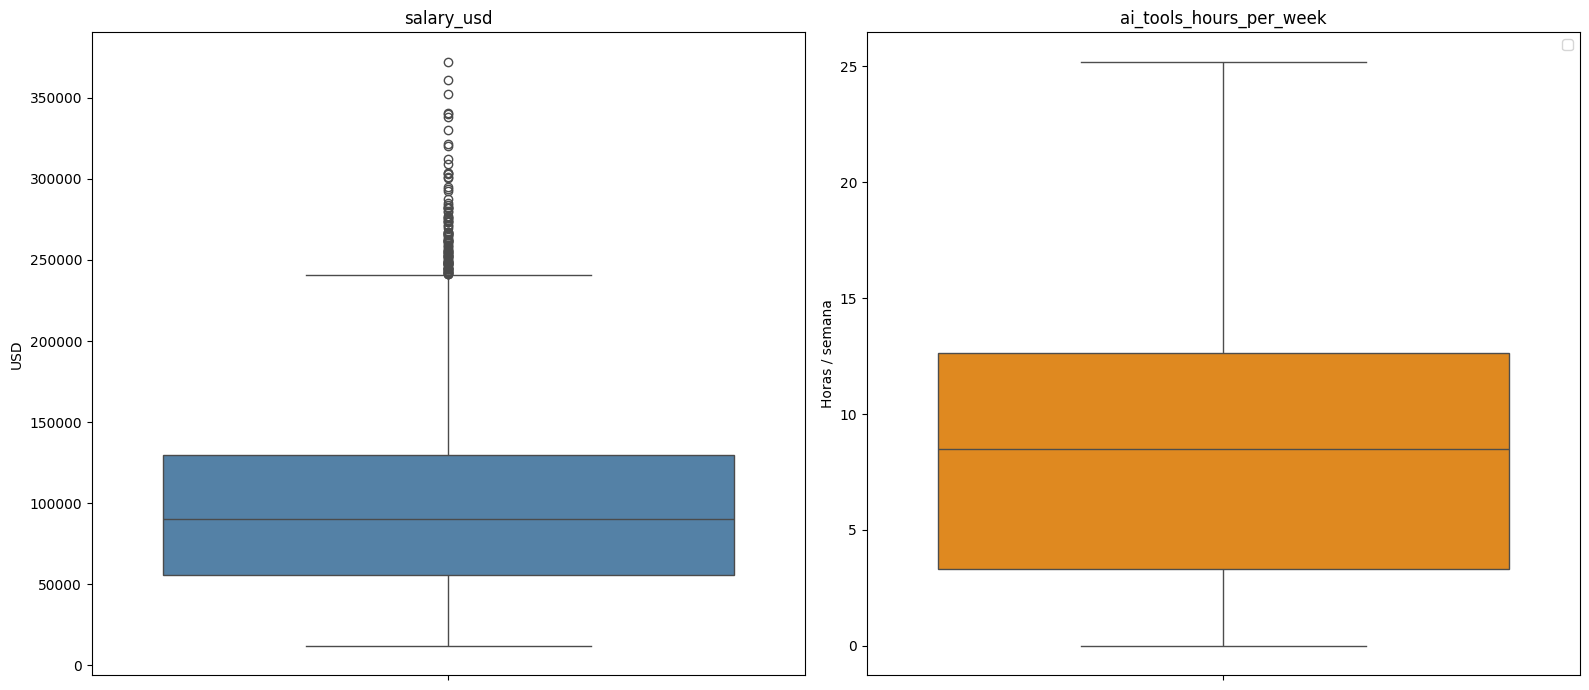

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.boxplot(y=df_sel["salary_usd"], ax=axes[0], color="steelblue")
axes[0].set_title("salary_usd")
axes[0].set_ylabel("USD")

sns.boxplot(y=df_sel["ai_tools_hours_per_week"], ax=axes[1], color="darkorange")
axes[1].set_title("ai_tools_hours_per_week")
axes[1].set_ylabel("Horas / semana")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
def resumen_outliers_iqr(serie, nombre):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out_mask = (serie < lower) | (serie > upper)
    print(f"{nombre}: límites IQR [{lower:,.2f}, {upper:,.2f}] | outliers: {out_mask.sum()} ({out_mask.mean():.2%})")
    return out_mask

# Chequeo compacto de IQR para todas las numéricas restantes (además de equity, que ya se trató aparte)
mask_salario = resumen_outliers_iqr(df_sel["salary_usd"], "salary_usd")
for c in ["ai_tools_hours_per_week", "years_experience", "team_size", "certifications_count",
          "weekly_hours", "bonus_pct", "job_satisfaction_score", "interviews_to_offer",
          "upskilling_hours_per_month", "fears_ai_automation_score"]:
    if c in df_sel.columns:
        resumen_outliers_iqr(df_sel[c], c)


salary_usd: límites IQR [-55,504.75, 240,755.25] | outliers: 103 (2.06%)
ai_tools_hours_per_week: límites IQR [-10.69, 26.61] | outliers: 0 (0.00%)
years_experience: límites IQR [-5.25, 21.55] | outliers: 20 (0.40%)
team_size: límites IQR [0.00, 16.00] | outliers: 10 (0.20%)
certifications_count: límites IQR [-2.00, 6.00] | outliers: 9 (0.18%)
weekly_hours: límites IQR [27.50, 61.10] | outliers: 25 (0.50%)
bonus_pct: límites IQR [-3.55, 24.85] | outliers: 13 (0.26%)
job_satisfaction_score: límites IQR [3.10, 10.30] | outliers: 27 (0.54%)
interviews_to_offer: límites IQR [-3.00, 13.00] | outliers: 11 (0.22%)
upskilling_hours_per_month: límites IQR [-3.55, 20.85] | outliers: 16 (0.32%)
fears_ai_automation_score: límites IQR [0.25, 9.45] | outliers: 24 (0.48%)


Todas las variables tienen una proporción de outliers estadísticos baja ( < 1% ). No necesitan modificaciones, son variaciones normales del dataset, no errores.

salary_usd sigue siendo la única con una propoorción mayor. Dado que en la siguiente fase entrenaremos modelos de Regresión, decidimos aplicar una winsorización. Acotamos estos valores extremos al límite inferior superior del rango IQR. Para mantener la trazabilidad de los datos, conservamos los valores originales en una nueva columna llamada salary_usd_win. Las demás variables numéricas no requirieron tratamiento estadístico adicional.


In [ ]:
# Calcular Q1, Q3 y el límite superior (IQR) para los salarios
q1, q3 = df_sel["salary_usd"].quantile([0.25, 0.75])
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr

# Mantener trazabilidad del dato original
df_sel["salary_usd_win"] = df_sel["salary_usd"]

# Aplicar winsorización al límite superior
df_sel["salary_usd"] = df_sel["salary_usd"].clip(upper=int(limite_superior))

n_afectados = (df_sel["salary_usd_win"] != df_sel["salary_usd"]).sum()

print(f"Límite superior estadístico aplicado: ${limite_superior:,.0f}")
print(f"Registros afectados por el ajuste: {n_afectados} ({n_afectados/len(df_sel):.2%})")

Límite superior estadístico aplicado: $240,755
Registros afectados por el ajuste: 103 (2.06%)


## EDA y visualizaciones estáticas 

## Distribución del salario y efecto del uso de IA por nivel de experienca
Para comenzar el EDA, primero analizamos la distribución de nuesta variable objetivo: salary_usd. Posteriormente, para abordar nuestra hipótesis principal, cruzamos los salarios con el nivel de experiencia y dividimos los grupos según si utilizan herramientas de IA diariamente o no. Esto nos permite observar visualmente si la IA genera una ventaja salarial dentro de cada categoría tradicional de experiencia.

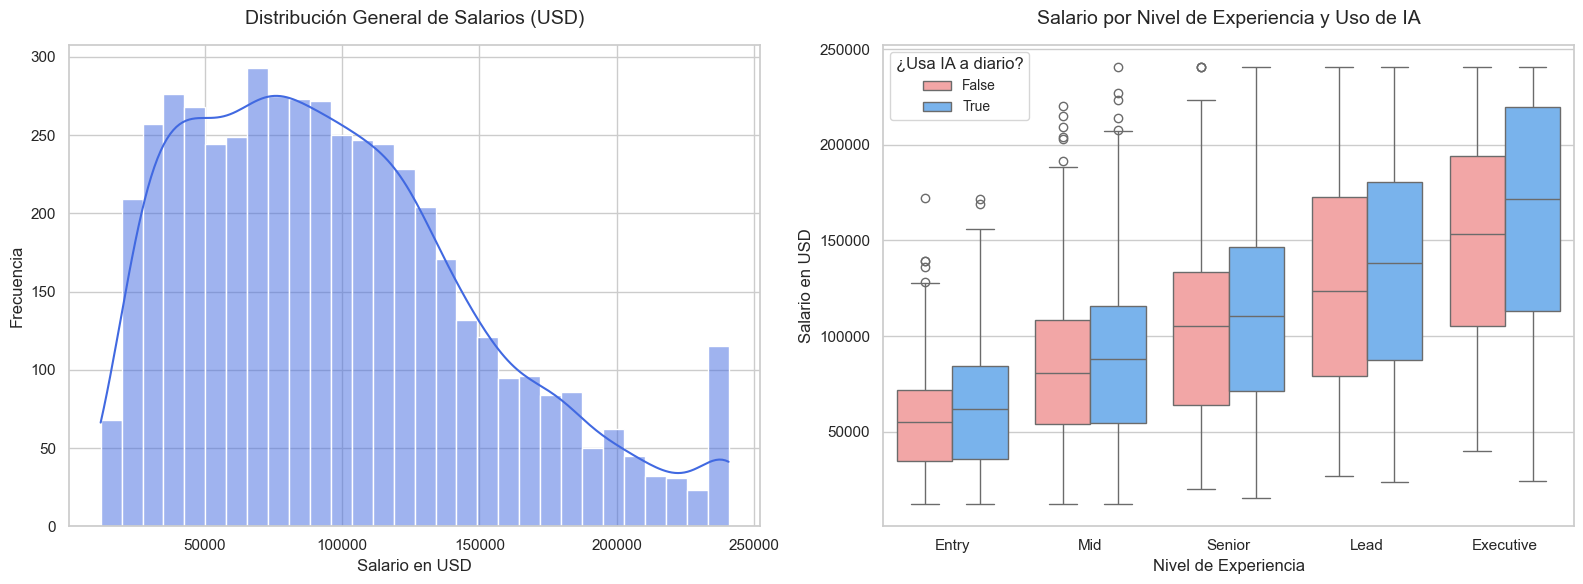

In [ ]:
# Configuración general de estilo para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Crear una figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Distribución del salario (Histograma + KDE)
sns.histplot(data=df_sel, x='salary_usd', kde=True, bins=30, color='royalblue', ax=axes[0])
axes[0].set_title("Distribución General de Salarios (USD)", fontsize=14, pad=15)
axes[0].set_xlabel("Salario en USD", fontsize=12)
axes[0].set_ylabel("Frecuencia", fontsize=12)

# Gráfico 2: Boxplot de Salario vs Experiencia, separado por Uso de IA
sns.boxplot(
    data=df_sel, 
    x='experience_level', 
    y='salary_usd', 
    hue='uses_ai_tools_daily', 
    palette=['#ff9999', '#66b3ff'], # Rojo suave (No usa IA), Azul (Sí usa IA)
    ax=axes[1]
)
axes[1].set_title("Salario por Nivel de Experiencia y Uso de IA", fontsize=14, pad=15)
axes[1].set_xlabel("Nivel de Experiencia", fontsize=12)
axes[1].set_ylabel("Salario en USD", fontsize=12)
axes[1].legend(title="¿Usa IA a diario?", fontsize=10)

plt.tight_layout()
plt.show()

- El histograma muestra que los salarios tienen una distribución normal, levemente sesgada a la derecha, concentrando su mayor volumen entre los $50.000 y $120.000 USD. 
- El gráfico de cajas revela que en casi todos los niveles de experiencia, especialmente entre los "Entry" y "Mid", la mediana salarial de quienes usan IA a diario tiende a posicionarse por encima de quienes no la usan. Esto nos da un primer indicio visual de que la IA efectivamente potencia la compensación económica.

#### Experiencia vs Salario
Para profundizar en nuestra hipotesis, analizamos la relación continua entre los años de experiencia y el salario mediante un gráfico de dispersión. Esto nos permite observar visualmente la distribución individual de los profesionales y detectar si el uso diario de IA logra elevar el salario en los primeros años de carrera.

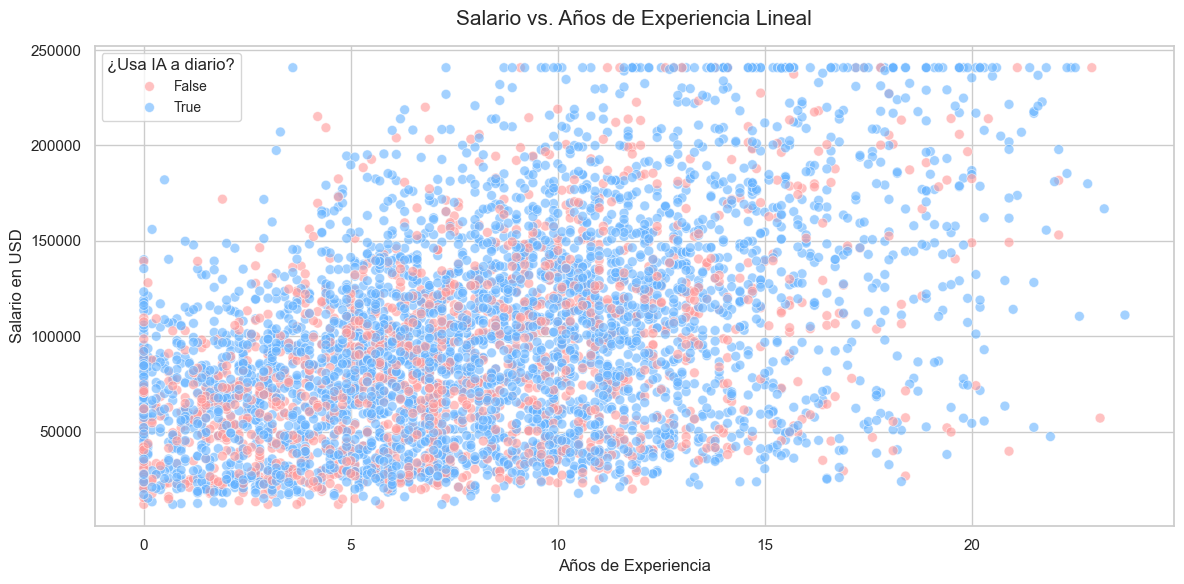

In [ ]:
plt.figure(figsize=(12, 6))

# Gráfico de Dispersión (Años de Experiencia vs Salario)
sns.scatterplot(
    data=df_sel, 
    x='years_experience', 
    y='salary_usd', 
    hue='uses_ai_tools_daily', 
    palette=['#ff9999', '#66b3ff'],
    alpha=0.6, 
    s=50      
)

plt.title("Salario vs. Años de Experiencia Lineal", fontsize=15, pad=15)
plt.xlabel("Años de Experiencia", fontsize=12)
plt.ylabel("Salario en USD", fontsize=12)
plt.legend(title="¿Usa IA a diario?", fontsize=10)

plt.tight_layout()
plt.show()

El gráfico confirma la tendencia natural de crecimiento: A mayor experiencia, mayor salario. Sin embargo, destaca una alta concentración de puntos azules (usuarios diarios de IA) que logran salarios elevados con menos de 10 años de experiencia. Esto reafirma que la IA actúa como un acelerador salarial frente a la trayectoria tradicional. En otras palabras, un profesional que domine y utilice intensivamente estas herramientas puede alcanzar una compensación equivalente a la de un colega que no las utiliza, incluso si este último posee el doble de años de experiencia.

### Mapa de calor de correlaciones
Finalmente, dentro del análisis construimos una matriz de correlación para identificar matemáticamente qué variables tienen la relación lineal más fuerte con nuestra variable objetivo (salary_usd).

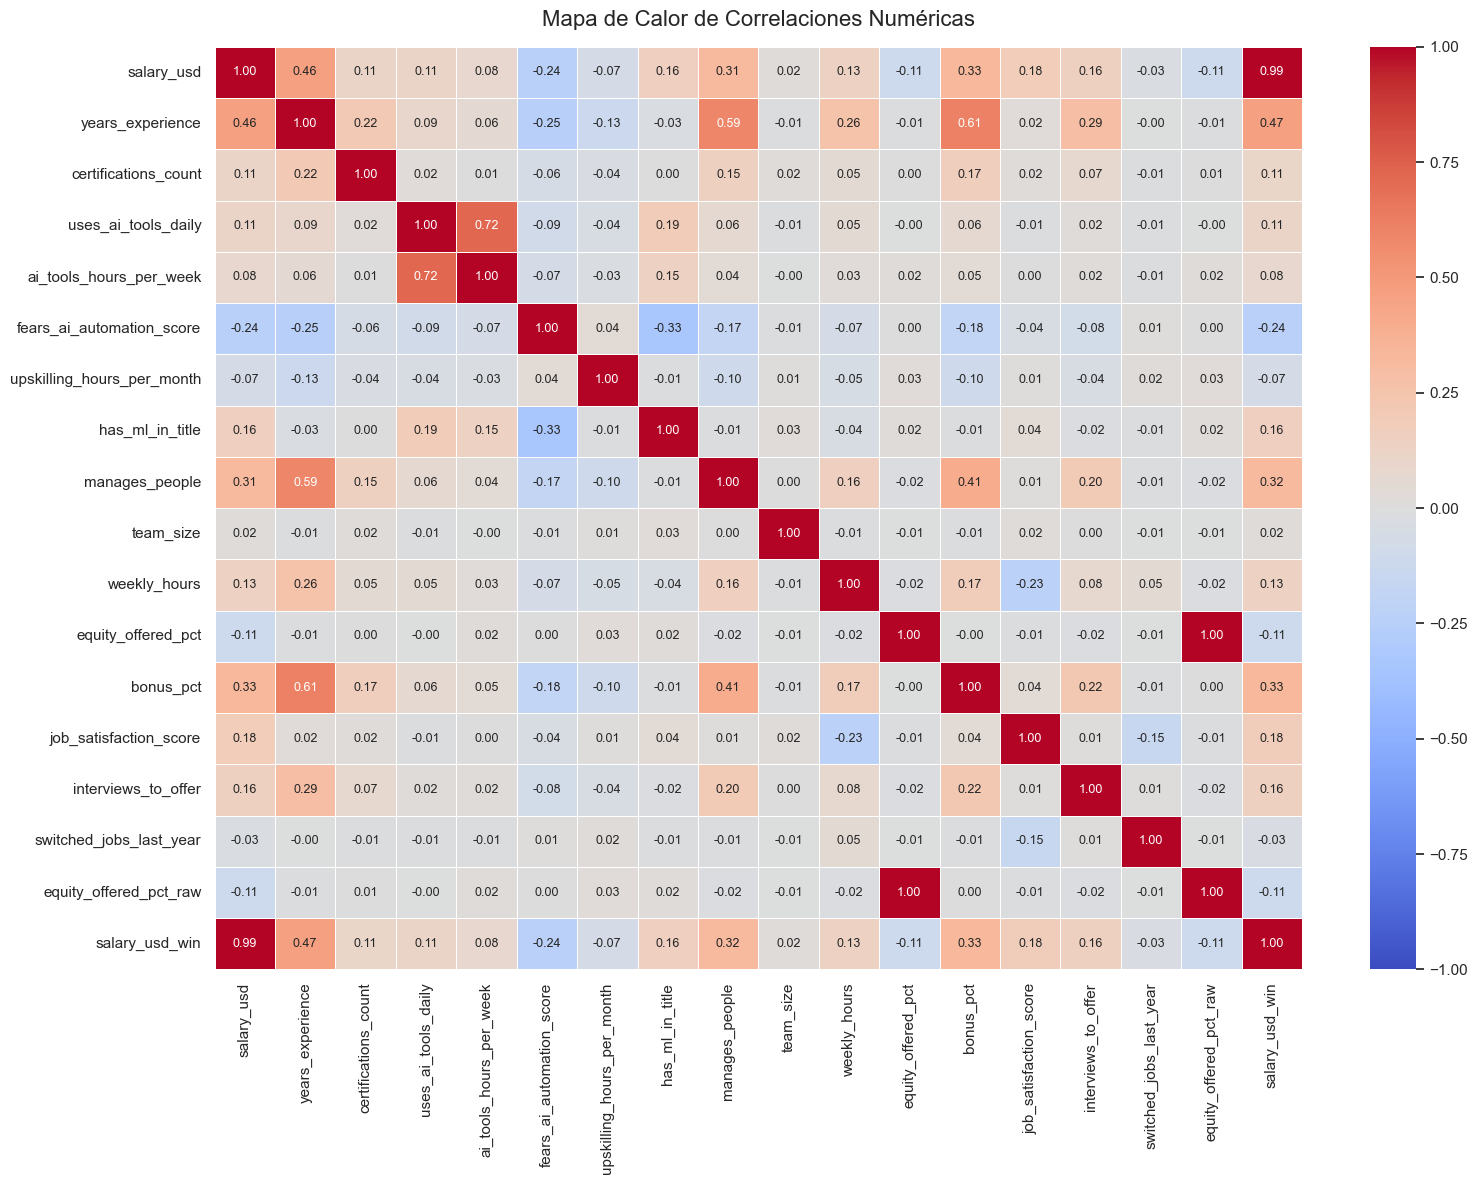

In [ ]:
# Hacemos la figura un poco más grande para que los números respiren bien
plt.figure(figsize=(16, 12))

# Seleccionamos solo las variables numéricas y booleanas para la matriz
cols_num = df_sel.select_dtypes(include=['number', 'bool']).columns
matriz_corr = df_sel[cols_num].corr()

# Generamos el heatmap
sns.heatmap(
    matriz_corr, 
    annot=True,            
    fmt=".2f",             
    annot_kws={"size": 9}, 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1,
    linewidths=0.5         
)

plt.title("Mapa de Calor de Correlaciones Numéricas", fontsize=16, pad=15)

plt.tight_layout()
plt.show()

Al examinar la correlación correspondinete a salary_usd, se confirman nuestros hallazgos previos: las variables que presentan una mayor correlación positiva con el suedo son los años de experiencia y las horas semanales dedicadas al uso de inteligencia artificial. De este modo, consolidamos numéricamente nuestra hipótesis de que la adopción intensiva de herramientas de IA genera un impacto directo, positivo y medible en la remuneración económica del profesional.

## Dashboard interactivo

Para enriqueces la exploración de datos, construimos un dashboard interactivo. 

#### Mapa temático: Salarios promedio por país.
El primer gráfico es un mapa temático que muestra la distribución geográfica de los salarios. Al agrupar los datos por la ubicación de la empresa, este mapa permite visualizar de forma interactiva dónde se concentran los mejores sueldos para los roles de Data Science a nivel global.

In [23]:
import plotly.express as px

# Calcular el sueldo promedio por cada país
df_mapa = df_sel.groupby('company_location', observed=True)['salary_usd'].mean().reset_index()

# Diccionario para adaptar los códigos de 2 letras (del dataset) a 3 letras (para Plotly)
iso3_map = {
    'US': 'USA', 'IN': 'IND', 'GB': 'GBR', 'DE': 'DEU',
    'CA': 'CAN', 'AU': 'AUS', 'BR': 'BRA', 'NL': 'NLD',
    'FR': 'FRA', 'PL': 'POL', 'SG': 'SGP', 'ES': 'ESP'
}
df_mapa['iso_alpha3'] = df_mapa['company_location'].map(iso3_map)

# Construir el mapa interactivo
fig1 = px.choropleth(
    df_mapa,
    locations="iso_alpha3",
    color="salary_usd",
    hover_name="company_location",
    color_continuous_scale=px.colors.sequential.YlOrRd, # Escala de colores (Amarillo a Rojo oscuro)
    title="Salario Promedio Global en Data Science & IA (USD)",
    labels={'salary_usd': 'Salario Promedio (USD)'}
)

fig1.update_layout(
    title_x=0.5,
    geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular')
)

fig1.show()

#### Top 10 cargos mejores pagados por filtro.
El segundo dashboard interactivo es un gráfico de barras dinámico. Utilizando un menú desplegable, el usuario puede alternar la vista para descubrir cuáles son los 10 roles mejor remunerados a nivel general, y cómo cambia este ranking si filtramos exclusivamente por empresas pequeñas (s), medianas (M) o grandes (L)

In [32]:
import plotly.graph_objects as go

# Obtener exactamente los 10 cargos top a nivel general 
top_10_trabajos = df_sel.groupby('job_title', observed=True)['salary_usd'].mean().nlargest(10)
nombres_top_10 = top_10_trabajos.index.tolist()

fig2 = go.Figure()

# Añadir el trazo por defecto (Promedio general de esos 10 cargos)
fig2.add_trace(go.Bar(
    x=nombres_top_10, y=top_10_trabajos.values, 
    name='General', visible=True, marker_color='indigo'
))

# Calcular y añadir los trazos para cada tamaño de empresa manteniendo el eje X fijo
tamanos = ['S', 'M', 'L']
colores = ['#ff9999', '#66b3ff', '#99ff99']

for size, color in zip(tamanos, colores):
    y_values = []
    for job in nombres_top_10:
        # Calcular el promedio específico para ese cargo y ese tamaño
        filtro = df_sel[(df_sel['job_title'] == job) & (df_sel['company_size'] == size)]
        if len(filtro) > 0:
            y_values.append(filtro['salary_usd'].mean())
        else:
            y_values.append(0) # Si no hay datos para ese cargo en ese tamaño
            
    fig2.add_trace(go.Bar(
        x=nombres_top_10, y=y_values, 
        name=f'Tamaño {size}', visible=False, marker_color=color
    ))

# Crear la lógica de los botones para el menú desplegable
botones = [
    dict(label="Todas las empresas", method="update", 
         args=[{"visible": [True, False, False, False]}, 
               {"title": "Salario de los Top 10 Cargos (General)"}]),
               
    dict(label="Empresas Pequeñas (S)", method="update", 
         args=[{"visible": [False, True, False, False]}, 
               {"title": "Salario de los Top 10 Cargos (Empresas Pequeñas)"}]),
               
    dict(label="Empresas Medianas (M)", method="update", 
         args=[{"visible": [False, False, True, False]}, 
               {"title": "Salario de los Top 10 Cargos (Empresas Medianas)"}]),
               
    dict(label="Empresas Grandes (L)", method="update", 
         args=[{"visible": [False, False, False, True]}, 
               {"title": "Salario de los Top 10 Cargos (Empresas Grandes)"}])
]

#Actualizar el diseño y agregar el menú
fig2.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=botones,
        direction="down",
        pad={"r": 10, "t": 10},
        showactive=True,
        x=0.0,
        xanchor="left",
        y=1.25,
        yanchor="top"
    )],
    title="Salario de los Top 10 Cargos",
    xaxis_title="Cargo Profesional",
    yaxis_title="Salario Promedio (USD)",
    showlegend=False,
    template="plotly_white",
    yaxis_range=[0, top_10_trabajos.max() * 1.1] # Fija la altura máxima para que no salte el eje Y

)

fig2.show()

#### Relación multivariable: experiencia, salario y adopción de IA
Como componente final del dashboard, presentamos un gráfico de burbujas que permite observar la interacción de cuatro variables simultáneamente. En este gráfico, los ejes representan la experiencia y el salario, el color diferencia a los usuarios diarios de IA de los que no, y el tamaño de la burbuja indica la cantidad de horas semanales dedicadas a estas herramientas.

In [33]:
fig3 = px.scatter(
    df_sel,
    x="years_experience",
    y="salary_usd",
    color="uses_ai_tools_daily",
    size="ai_tools_hours_per_week",
    hover_data=['job_title', 'experience_level'], # Muestra más info al pasar el mouse
    color_discrete_sequence=['#66b3ff', '#ff9999'], # Azul (True), Rojo (False)
    labels={
        "years_experience": "Años de Experiencia",
        "salary_usd": "Salario (USD)",
        "uses_ai_tools_daily": "¿Usa IA a Diario?",
        "ai_tools_hours_per_week": "Horas/Semana IA",
        "job_title": "Cargo"
    },
    title="Impacto Multivariable: Experiencia, Salario y Adopción de IA (Dataset Completo)"
)

# Ajustes visuales
fig3.update_layout(
    title_x=0.5,
    template="plotly_white",
    xaxis=dict(showgrid=True),
    yaxis=dict(showgrid=True)
)

fig3.show()

Los gráficos estáticos muestran una foto fija de la información, en cambio, este dashboard permite desglosar la complejidad del mercado laboral en tiempo real mediante menús desplegables, capas geográficas y filtros dinámicos.
Gracias a la interactividad, el usuario no se limita a solo observar una tendencia general, sino que puede aislaar segmentos en especificos que busque o examinar los detalles exactos de un punto.
